In [ ]:
# pip install datasets

**Import tools**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader
from datasets import Dataset

**Load dataset**

In [ ]:
data = pd.read_csv("/content/Combined Data.csv")

data = data.drop(columns=['Unnamed: 0'])
data.dropna(inplace=True)

data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [ ]:
data = data.sample(n=6000,).reset_index(drop=True)
data

,statement,status
0,My parents separated when I was 9 and since th...,Suicidal
1,let say i m on probation and let say i have a ...,Depression
2,"Find it hard to care anymore Simple as, just d...",Depression
3,I cannot keep going like this. I had a suicide...,Suicidal
4,32 years of fight and I have not got another r...,Suicidal
...,...,...
5995,title i am currently looking at getting onto m...,Depression
5996,Scaring myself I have cancer? Basically what i...,Anxiety
5997,I have actually cried with joy and relief when...,Suicidal
5998,i d give anything to die i can t take this pai...,Depression


**Data Processing**


1. Cleaning

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_statement(statement):

    statement = statement.lower()

    statement = re.sub(r'[^\w\s]', '', statement)

    statement = re.sub(r'\d+', '', statement)

    words = statement.split()

    words = [word for word in words if word not in stop_words]

    cleaned_statement = ' '.join(words)

    return cleaned_statement

data['statement'] = data['statement'].apply(clean_statement)

data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,statement,status
0,parents separated since everything went wrong ...,Suicidal
1,let say probation let say traffic citation let...,Depression
2,find hard care anymore simple dont know state ...,Depression
3,cannot keep going like suicide attempt year ha...,Suicidal
4,years fight got another round give throw towel...,Suicidal
...,...,...
5995,title currently looking getting onto med anxie...,Depression
5996,scaring cancer basically says left armpit noti...,Anxiety
5997,actually cried joy relief really think suicide...,Suicidal
5998,give anything die take pain anymore,Depression


2. Balance Dataset

In [ ]:
data['status'].value_counts()

,count
status,
Normal,1853
Depression,1764
Suicidal,1208
Anxiety,462
Bipolar,328
Stress,268
Personality disorder,117


**Sampling**

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

X = data.drop(columns=['status'])
y = data['status']

X_resampled, y_resampled = ros.fit_resample(X, y)

data = pd.concat([X_resampled, y_resampled], axis=1)

print(data['status'].value_counts())


status
Suicidal                1853
Depression              1853
Bipolar                 1853
Anxiety                 1853
Stress                  1853
Normal                  1853
Personality disorder    1853
Name: count, dtype: int64


**Label Encoding**

In [ ]:

label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['status'])

# Traditional ML - Train/Test Split

In [ ]:
X = data['statement']
y = data['label']

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_test_tfidf = tfidf.transform(X_test_ml)

# Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

ml_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

ml_model.fit(X_train_tfidf, y_train_ml)

LogisticRegression(max_iter=1000, random_state=42)

#Traditional ML Results

In [ ]:
# Predictions

ml_predictions = ml_model.predict(X_test_tfidf)

In [ ]:
# Classification Report

print(classification_report(
    y_test_ml,
    ml_predictions,
    target_names=label_encoder.classes_
))

                      precision    recall  f1-score   support

             Anxiety       0.95      0.98      0.97       370
             Bipolar       0.97      0.98      0.98       370
          Depression       0.72      0.62      0.67       371
              Normal       0.86      0.93      0.89       371
Personality disorder       0.98      1.00      0.99       371
              Stress       0.96      0.97      0.97       371
            Suicidal       0.74      0.73      0.74       371

            accuracy                           0.89      2595
           macro avg       0.88      0.89      0.89      2595
        weighted avg       0.88      0.89      0.89      2595



In [ ]:
# Accuracy

from sklearn.metrics import accuracy_score

ml_accuracy = accuracy_score(y_test_ml, ml_predictions)

print("Traditional ML Accuracy:", ml_accuracy)

Traditional ML Accuracy: 0.8882466281310212


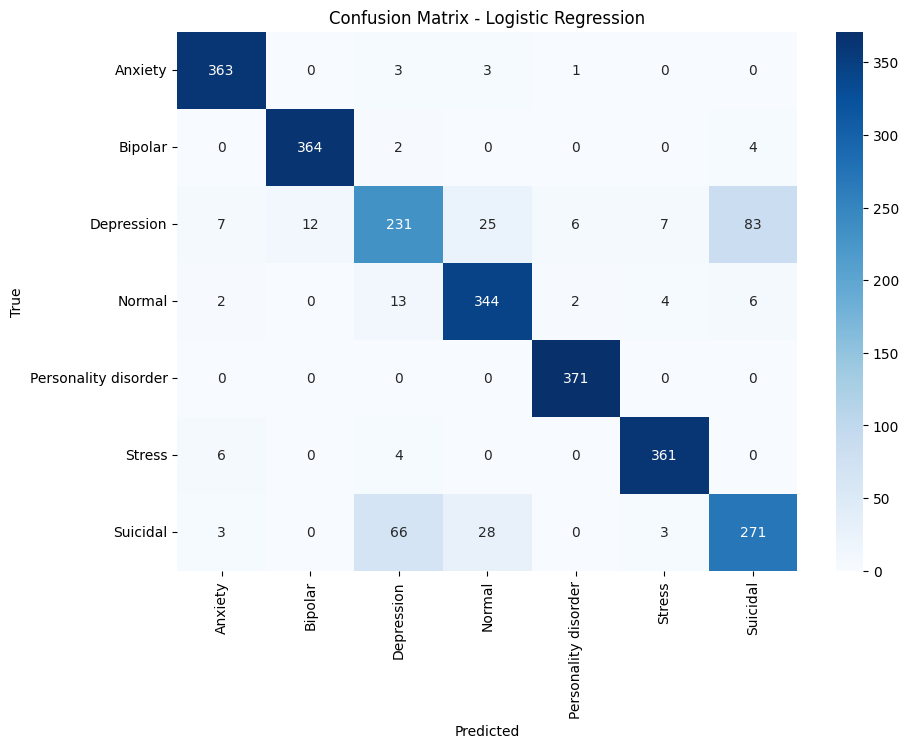

In [ ]:
# Confusion Matrix

cm_ml = confusion_matrix(y_test_ml, ml_predictions)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_ml,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

# Train Test Split

In [ ]:

train_texts, test_texts, train_labels, test_labels = train_test_split(data['statement'], data['label'], test_size=0.2)

In [ ]:
max([len(text) for text in data['statement']])

25199

# Tokenization

In [ ]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


train_encodings = tokenizer(list(train_texts), padding=True, truncation=True, max_length=200)
test_encodings = tokenizer(list(test_texts), padding=True, truncation=True, max_length=200)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Convert to Dataset format
train_dataset = Dataset.from_dict({'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask'], 'labels': train_labels.tolist()})
test_dataset = Dataset.from_dict({'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask'], 'labels': test_labels.tolist()})\



# Fine Tuning Bert

In [ ]:
BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(label_encoder.classes_))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    lr_scheduler_type="linear",
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=3,
    gradient_accumulation_steps=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)


trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `loggin

Epoch,Training Loss,Validation Loss
1,2.146373,0.980018
2,0.840754,0.359839
3,0.523347,0.276135
4,0.309898,0.238949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

#  Model Evaluation


In [ ]:

predictions, labels, _ = trainer.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

print(classification_report(test_labels, predicted_labels, target_names=label_encoder.classes_))

cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'trainer' is not defined

# Save and Load Model and Tokenizer

In [ ]:

trainer.save_model('/content/drive/Mydrive/saved_mental_status_bert')
tokenizer.save_pretrained("/content/drive/Mydrive/saved_mental_status_bert")

import pickle

pickle.dump(label_encoder, open('/content/drive/Mydrive/label_encoder.pkl', 'wb'))

from transformers import AutoModelForSequenceClassification, AutoTokenizer


model = AutoModelForSequenceClassification.from_pretrained("/content/drive/Mydrive/saved_mental_status_bert")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/Mydrive/saved_mental_status_bert")

label_encoder = pickle.load(open('/content/drive/Mydrive/label_encoder.pkl', 'rb'))

NameError: name 'trainer' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# from transformers import AutoModelForSequenceClassification, AutoTokenizer


# model = AutoModelForSequenceClassification.from_pretrained("/content/drive/Mydrive/saved_mental_status_bert")
# tokenizer = AutoTokenizer.from_pretrained("/content/drive/Mydrive/saved_mental_status_bert")

# label_encoder = pickle.load(open('/content/drive/Mydrive/label_encoder.pkl', 'rb'))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

# Detection System

In [ ]:

def detect_anxiety(text):
    cleaned_text = clean_statement(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    return label_encoder.inverse_transform([predicted_class])[0]


sample_texts = [
    "I feel perfectly fine today, nothing to worry about.",
    "I can't stop thinking about what will happen if things go wrong.",
    "Lately, I've been on a high, feeling like I can do anything!",
    "I'm so sad, I just can't seem to get out of bed anymore.",
    "I'm constantly thinking about how much better everyone else is doing than me.",
    "I don't think I can keep going, everything feels so hopeless.",
    "I had a really good day, spent some time with my friends.",
    "I'm overwhelmed by the idea that I might lose everything.",
    "I feel like nothing matters anymore, I just want to give up.",
    "I'm okay today, but sometimes I get really anxious for no reason."
]


for text in sample_texts:
    predicted_class = detect_anxiety(text)
    print(f"Sentence: {text}\nPredicted class: {predicted_class}\n")


Sentence: I feel perfectly fine today, nothing to worry about.
Predicted class: Anxiety

Sentence: I can't stop thinking about what will happen if things go wrong.
Predicted class: Normal

Sentence: Lately, I've been on a high, feeling like I can do anything!
Predicted class: Normal

Sentence: I'm so sad, I just can't seem to get out of bed anymore.
Predicted class: Normal

Sentence: I'm constantly thinking about how much better everyone else is doing than me.
Predicted class: Depression

Sentence: I don't think I can keep going, everything feels so hopeless.
Predicted class: Depression

Sentence: I had a really good day, spent some time with my friends.
Predicted class: Normal

Sentence: I'm overwhelmed by the idea that I might lose everything.
Predicted class: Stress

Sentence: I feel like nothing matters anymore, I just want to give up.
Predicted class: Suicidal

Sentence: I'm okay today, but sometimes I get really anxious for no reason.
Predicted class: Anxiety



# Downlaod Model To Your PC Directly

In [ ]:
import shutil
from google.colab import files

model_save_path = "saved_mental_status_bert"
tokenizer_save_path = "saved_mental_status_bert"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)

zip_file_path = "saved_mental_status_bert"

shutil.make_archive(zip_file_path, 'zip', root_dir='saved_mental_status_bert', base_dir='')

files.download(f"{zip_file_path}.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>